# Деревья решений и композиции

In [20]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from pprint import pprint

В этой лабораторной вам предстоит поработать с двумя задачами сразу: классификацией и регрессией. Задача классификации в машинном обучении - это один из основных типов задач, где модель обучается предсказывать категориальную метку или класс для заданного входного наблюдения на основе обучающего набора данных, содержащего пары "входные данные - целевая метка".

Можно выделить несколько видов классификации:

* Binary - целевой признак имеет метку 0/1;
* Multiclass - целевой признак имеет метку из ограниченного множества (0, 1, 2, 3...);
* Multilabel - целевой признак может иметь несколько меток одновременно.

Классификацию можно решать как задачу регрессии (задача предсказания значения из непрерывного множества), затем выбирая порог - всем значениям меньше порога будет присвоена метка 0, всем значениям выше - метка 1.

# Деревья решений

Решающие деревья - алгоритм машинного обучения, с помощью которого можно решать задачи классификации и регрессии. Основная идея алгортитма - это поиск условий принятия решений по тренировочным данным.

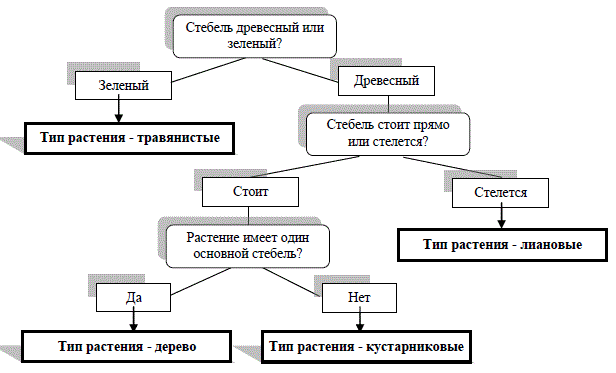

По сути, мы рекурсивно разбиваем наши обучающие данные по значениям определенного столбца, чтобы по итогу в каждом листе оказались наиболее однородные значения целевой переменной.

## Построение дерева

Опишем жадный алгоритм построения бинарного дерева решений:
1. Начинаем со всей обучающей выборки $X$, которую помещаем в корень $R_1$.
2. Задаём функционал качества $Q(X, j, t)$ и критерий остановки.
3. Запускаем построение из корня: $SplitNode(1, R_1)$

Функция $SplitNode(m, R_m)$
1. Если выполнен критерий остановки, то выход.
2. Находим наилучший с точки зрения $Q$ предикат: $j, t$: $[x_j<t]$
3. Помещаем предикат в вершину и получаем с его помощью разбиение $X$ на две части: $R_{left} = \lbrace x|x_j<t \rbrace$ и $R_{right} = \lbrace x|x_j \geqslant t \rbrace$
4. Поместим $R_{left}$ и $R_{right}$ соответсвенно в левое и правое поддерево.
5. Рекурсивно повторяем $SplitNode(left, R_{left})$ и $SplitNode(right, R_{right})$.

В конце поставим в соответствие каждому листу ответ. Для задачи классификации - это самый частый среди объектов класс или вектор с долями классов (можно интерпретировать как вероятности):
$$ c_v = \arg \max_{k\in Y} \sum_{(x_i,y_i) \in R_v} [y_i=k]  $$


Небольшое дополнение, чтобы стало понятнее: $Q$ - это функционал, который определяет то, что мы называем "наилучшим разбиением" для данных на каждом шаге. То есть мы выбираем один столбец, потом для него выбираем число $t$ такое, что часть значений столбца меньше $t$, а оставшаяся часть - больше или равна (дерево работает только с числовыми значениями или с категориальными, если они переведены в числовой формат), и смотрим, что случилось с целевой переменной при таком разбиении. Если допустить, что целевая переменная бинарная (0/1) и до разбиения нолики и единички лежали кучей, то после разбиения мы в идеале хотим получить две кучки, где в одной только нули, а в другой только единицы.

## Функционал качества для деревьев решений


Для классификации чаще всего предлагают следующие два:

- энтропия Шеннона: $-\sum_k{p_{ik}log_2(p_{ik})}$

- индекс Джини: $\sum_{j\neq k}p_{ij}p_{ik} = 1 - \sum_k p_{ik}^2$

где:

* $i$ - ID узлов дерева;

* $k, j$ - идентификаторы классов, представленных в датасете;

* $p_{ik} = \frac{N_{ik}}{N_i}$,

* $p_{ik}$ - вероятность принадлежности класса $k$ узлу $i$,

* $N_{ik}$ - число объектов класса $k$ в узле $i$,

* $N_{i}$ - общее число объектов в узле $i$.



Оба функционала позволяют определить степень хаоса в системе. Интуитивно:
* 0101101010101 - высокая степень хаоса
* 0000010010000 - средняя степень хаоса
* 0000000000000 - низкая степень хаоса

И с помощью дерева для целевой переменной мы хотим добиться чего-то вроде:
0001100011111 -> 00011000 + 11111 -> 000 + 11000 + 11111 -> 000 + 11 + 000 + 11111

Для регрессии в качестве функциона качества можно использовать, например, MSE: $\frac{1}{N_i} \sum_{j=1}^{N_i} (y_j - \bar{y}_i)^2$

где:
* $i$ — ID узла дерева;
* $N_i$ — число объектов в узле $i$;
* $y_j$ — значение целевой переменной для объекта $j$;
* $\bar{y}_i$ — среднее значение ответов в узле, которое вычисляется как:
$$\bar{y}_i = \frac{1}{N_i} \sum_{j=1}^{N_i} y_j$$

Если в классификации индекс Джини или энтропия показыват степень хаоса в распределении меток, то в регрессии MSE показывает дисперсию ответов. Чем ниже значение, тем более похожи числа в узле друг на друга. Другими словами, в задаче классификации мы измеряем чистоту классов, а в регрессии – однородность числовых значений. Поэтому при поиске лучшего разбиения признаки и пороги подбираются так, чтобы минимизировать сумму MSE в левом и правом листьях.

Реализуйте функционалы.

In [21]:
import seaborn as sns


def entropy(y):  # y - массив значений целевой переменной
    y = np.asarray(y)
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))


def gini_index(y):
    y = np.asarray(y)
    _, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)


def mse(y):
    y = np.asarray(y)
    return np.mean((y - y.mean()) ** 2) if len(y) else 0.0


mse_node = mse  # section 3 redefines `mse` with another signature; trees keep using this alias


In [22]:
# Tests

assert np.isclose(entropy([0, 1, 0, 1, 0, 1]), 1.0)
assert np.isclose(entropy([0, 0, 0, 0, 0, 1]), 0.65, atol=1e-2)
assert np.isclose(entropy([0, 1, 2, 0, 1, 2, 0, 1, 2]), 1.58, atol=1e-2)

assert np.isclose(gini_index([0, 1, 0, 1, 0, 1]), 0.5)
assert np.isclose(gini_index([0, 0, 0, 0, 0, 1]), 0.27, atol=1e-2)
assert np.isclose(gini_index([0, 1, 2, 0, 1, 2, 0, 1, 2]), 0.66, atol=1e-2)

assert np.isclose(mse([5, 5, 5, 5]), 0.0)
assert np.isclose(mse([1, 2, 3]), 0.66, atol=1e-2)
assert np.isclose(mse([0, 10, 20]), 66.66, atol=1e-2)

assert entropy([0, 0, 0, 0, 0, 0]) == gini_index([0, 0, 0, 0, 0, 0]) == mse([0, 0, 0, 0, 0, 0]) == 0.0

print("All tests passed successfully!")

All tests passed successfully!


Энтропия – по сути степень хаоса (или неопределенности) в системе. Уменьшение энтропии называют приростом информации (information gain, IG).

Обочначим $R_v$ - объекты, которые нужно разделить в помощью предиката в вершине $v$. Запишем формулу для расчёта информационного прироста:
$$ Q = IG = H(R_v) - (H(R_{left})+H(R_{right}))$$

На каждом шаге нам нужно максимизировать этот функционал качества. Как это делать? Например, можно перебрать $t$ для выбранного $j$.

Предыдущая версия формулы прироста информации слишком упрощена. В работе необходимо использовать более устойчивую формулу, которая учитывает не только энтропию подмножеств, но и их размер.

$$ Q = IG = H(R_v) - \Big (\frac{|R_{left}|} {|R_{v}|} H(R_{left})+ \frac{|R_{right}|} {|R_{v}|} H(R_{right})\Big)$$

где, $|R_{v}|$, $|R_{left}|$ и $|R_{right}|$ - количество элементов в соответствующих множествах.


## Задание 1 (5 баллов)

### Задание 1.1: Классификация

Реализуйте алгоритм построения дерева. Должны быть отдельные функции (методы) для расчёта энтропии (уже есть), для разделения узлов дерева (используйте, например, `pandas`), для подсчёта функционала качества $IG$, для выбора наилучшего разделения (с учетом признаков и порогов), для проверки критерия остановки.

Для набора данных `iris` реализуйте алгоритм и минимум три разных критерия остановки из перечисленных ниже:
* максимальной глубины дерева = 5
* минимального числа объектов в листе = 5
* максимальное количество листьев в дереве = 5
* purity (остановка, если все объекты в листе относятся к одному классу)

В классе `Tree` реализуйте метод `predict` (на вход метода подаётся датафрейм с объектами)

Оцените точность каждой модели с помощью метрики доля правильных ответов (`from sklearn.metrics import accuracy_score` или реализовать свою). Обратите внимание на то, что классы в датасете представлены одинаковым количеством объектов.

In [23]:
class TreeNode:
    def __init__(self):
        self.is_leaf = True
        self.prediction = None
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None


class Tree:
    def __init__(self, criterion=entropy, max_depth=None, min_samples_leaf=1, purity_stop=True):
        self.criterion = criterion
        self.max_depth = max_depth if max_depth is not None else np.inf
        self.min_samples_leaf = min_samples_leaf
        self.purity_stop = purity_stop  # критерий остановки: все объекты листа одного класса
        self.n_leaves = 0
        self.root = None

    def _leaf_value(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _should_stop(self, y, depth):
        if depth >= self.max_depth:  # критерий остановки: максимальная глубина
            return True
        if len(y) < 2 * self.min_samples_leaf:  # критерий остановки: минимум объектов в листе
            return True
        if self.purity_stop and len(np.unique(y)) == 1:
            return True
        return False

    def _best_split(self, X, y):
        best_gain, best_feature, best_threshold = 0.0, None, None
        parent_score = self.criterion(y)
        n = len(y)
        for j in range(X.shape[1]):
            for t in np.unique(X[:, j]):
                left_mask = X[:, j] < t
                n_left = left_mask.sum()
                n_right = n - n_left
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue
                gain = parent_score - (n_left / n * self.criterion(y[left_mask])
                                        + n_right / n * self.criterion(y[~left_mask]))
                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, j, t
        return best_feature, best_threshold

    def _build(self, X, y, depth):
        node = TreeNode()
        feature, threshold = (None, None) if self._should_stop(y, depth) else self._best_split(X, y)

        if feature is None:
            node.prediction = self._leaf_value(y)
            self.n_leaves += 1
            return node

        left_mask = X[:, feature] < threshold
        node.is_leaf = False
        node.feature, node.threshold = feature, threshold
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        X = X.values if hasattr(X, 'values') else np.asarray(X)
        y = y.values if hasattr(y, 'values') else np.asarray(y)
        self.n_leaves = 0
        self.root = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        while not node.is_leaf:
            node = node.left if x[node.feature] < node.threshold else node.right
        return node.prediction

    def predict(self, X):
        X = X.values if hasattr(X, 'values') else np.asarray(X)
        return np.array([self._predict_one(x, self.root) for x in X])


Один из варинтов того, как может выглядеть дерево (в данном случае переобученное).

Вам не обязательно реализовывать функционал для визуализации, это просто пример. Но если хочется - посмотрите в сторону библиотеки [graphviz](https://graphviz.org/).


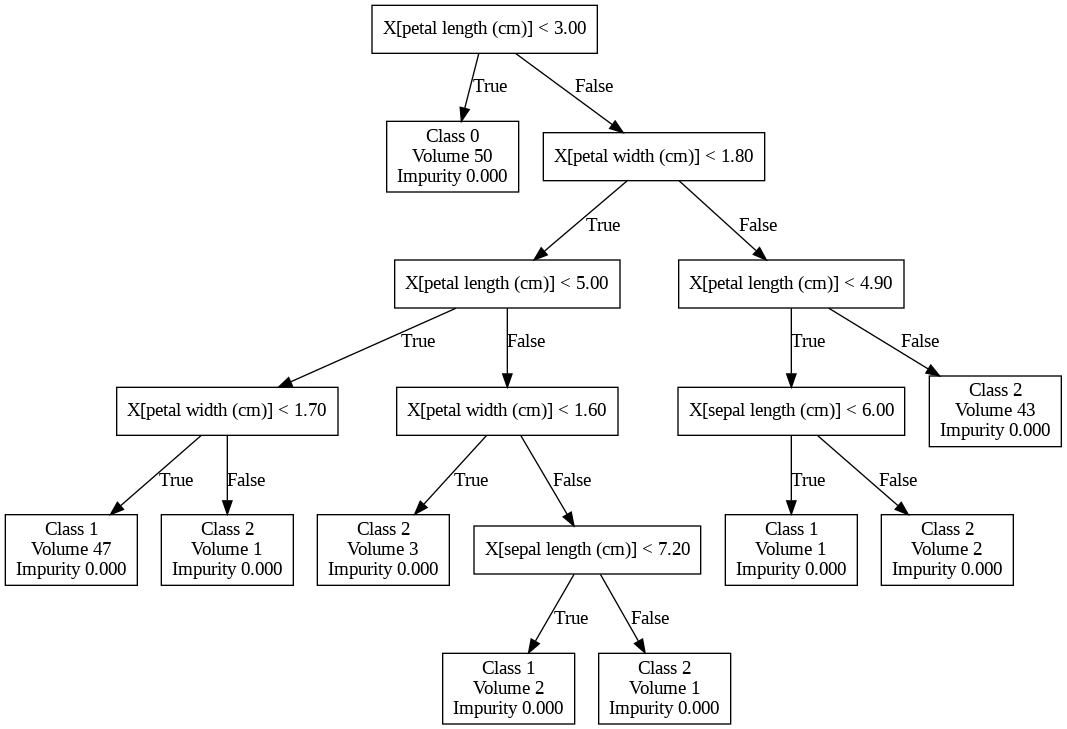

In [24]:
from sklearn import datasets
from sklearn.model_selection import train_test_split  # при оценке вашего алгоритма не забудьте разбить данные на тренировочную и тестовую выборки
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier  # можете сравнить качество вашего алгоритма с реализацией "из коробки"


iris = datasets.load_iris()
X = iris['data']
feature_names = iris['feature_names']
y = iris['target']
target_names = iris['target_names']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

configs = {
    'max_depth=5': dict(max_depth=5, min_samples_leaf=1, purity_stop=False),
    'min_samples_leaf=5': dict(max_depth=None, min_samples_leaf=5, purity_stop=False),
    'purity_stop': dict(max_depth=None, min_samples_leaf=1, purity_stop=True),
}

for name, kwargs in configs.items():
    tree = Tree(criterion=entropy, **kwargs)
    tree.fit(X_train, y_train)
    acc = accuracy_score(y_test, tree.predict(X_test))
    print(f'{name}: accuracy={acc:.3f}, leaves={tree.n_leaves}')

sk_tree = DecisionTreeClassifier(random_state=42)
sk_tree.fit(X_train, y_train)
print('sklearn DecisionTreeClassifier:', accuracy_score(y_test, sk_tree.predict(X_test)))


max_depth=5: accuracy=0.911, leaves=7
min_samples_leaf=5: accuracy=0.889, leaves=5
purity_stop: accuracy=0.911, leaves=8
sklearn DecisionTreeClassifier: 0.9333333333333333


### Задание 1.2: Регрессия

Напишите класс `TreeRegressor`, модифицировав класс `Tree` под решение задачи регрессии.

Протестируйте и оцените работу класса на задаче предсказания продолжительности жизни: https://www.kaggle.com/datasets/byazitmustafayev/life-expectancy-factors-2000-2019

Часть признаков в датасете требует предобработки. Проведите ее и обоснуйте.

Критерии остановки используйте те же, что в задании 1.1, но с поправкой на регрессию.

Для оценки качества предсказания выберите не менее трех метрик.

In [26]:
%%capture

!pip install opendatasets

In [27]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/byazitmustafayev/life-expectancy-factors-2000-2019")

Skipping, found downloaded files in ".\life-expectancy-factors-2000-2019" (use force=True to force download)


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class TreeRegressor(Tree):
    def __init__(self, max_depth=None, min_samples_leaf=1, purity_tol=None):
        super().__init__(criterion=mse_node, max_depth=max_depth, min_samples_leaf=min_samples_leaf, purity_stop=False)
        self.purity_tol = purity_tol  # аналог purity для регрессии: остановка, если MSE узла (дисперсия ответов) < purity_tol

    def _should_stop(self, y, depth):
        if self.purity_tol is not None and mse_node(y) < self.purity_tol:
            return True
        return super()._should_stop(y, depth)

    def _leaf_value(self, y):
        return np.mean(y)


# те же критерии, что в 1.1: глубина 5, мин. объектов в листе 5, purity (для регрессии - малая дисперсия в узле)
REG_CONFIGS = {
    'max_depth=5': dict(max_depth=5, min_samples_leaf=1),
    'min_samples_leaf=5': dict(max_depth=None, min_samples_leaf=5),
    'purity (mse<0.01)': dict(max_depth=None, min_samples_leaf=1, purity_tol=0.01),
}

life = pd.read_csv('life-expectancy-factors-2000-2019/life expectancy.csv')
life['Year'] = life['Year'].str.slice(0, 4).astype(int)
# Country Name/Code - строковые id с 179 уникальными значениями, дереву от них пользы нет
life = life.drop(columns=['index', 'Country Name', 'Country Code'])

X_life = life.drop(columns='Life_Expectancy')
y_life = life['Life_Expectancy']
X_train_life, X_test_life, y_train_life, y_test_life = train_test_split(
    X_life, y_life, test_size=0.3, random_state=42)

for name, kwargs in REG_CONFIGS.items():
    reg = TreeRegressor(**kwargs)
    reg.fit(X_train_life, y_train_life)
    preds = reg.predict(X_test_life)
    print(f'{name}: MSE={mean_squared_error(y_test_life, preds):.3f} '
          f'MAE={mean_absolute_error(y_test_life, preds):.3f} R2={r2_score(y_test_life, preds):.3f}')


max_depth=5: MSE=10.981 MAE=2.267 R2=0.845
min_samples_leaf=5: MSE=7.069 MAE=1.648 R2=0.900
purity (mse<0.01): MSE=8.830 MAE=1.597 R2=0.875


#  [Ансамбли](https://education.yandex.ru/handbook/ml/article/ansambli-v-mashinnom-obuchenii)




Суть ансамблей заключается в том, чтобы объединить предсказания стандартных моделей для повышения обобщающей способности или надёжности ансамбля перед одиночным стандартным методом машинного обучения.

Можно выделить следующие типы ансамблирования:

* Бэггинг. Однотипная модель строится по различным подвыборкам обучающих данных, затем результаты аггрегируются, например, с помощью усреднения. Для деревьев решений очень распространенным алгоритмом, использующим идею бэггинга, является случайный лес.

* Бустинг. Строится последовательность однотипных моделей, где каждая следующая призвана исправлять ошибки предыдущих. Самым распространенным алгоритмом бустинга является градиентный бустинг.

* Стэкинг. Строится несколько моделей разного типа, а также мета-модель, делающая итоговое предсказание на основании предсказаний моделей.

Для последующих заданий в качестве набора данных используйте: https://www.kaggle.com/mathchi/churn-for-bank-customers

Там есть описание и примеры работы с этими данными. Если кратко, речь идёт про задачу прогнозирования оттока клиентов. Есть данные о 10 тысячах клиентов банка, часть из которых больше не являются клиентами.

Обратите внимание, что данные нуждаются в небольшой предобаботке, так как деревья работают только с числовыми признаками.


### Задание 2.1 (2 балла)

Опишем алгоритм случайный лес (*random forest*) и попутно разберём основные идеи бэггинга:

1. Зададим $N$ - число деревьев в лесу.
2. Для каждого $n$ из $N$ сгенерируем свою выборку $X_n$. Пусть $m$ - это количество объектов в $X$. При генерации каждой $X_n$ мы будем брать объекты $m$ раз с возвращением. То есть один и тот же объект может попасть в выборку несколько раз, а какие-то объекты не попадут. (Этот способ назвается бутстрап).
3. По каждой $X_n$ построим решающее дерево $b_n$. Обычно стараются делать глубокие деревья. В качестве критериев остановки можно использовать `max_depth` или `min_samples_leaf` (например, пока в каждом листе не окажется по одному объекту). При каждом разбиении сначала выбирается $k$ (эвристика $k = \sqrt d$, где $d$ - это число признаков объектов из выборки $X$) случайных признаков из исходных, и оптимальное разделение выборки ищется только среди них. Обратите внимание, что мы не выбрасываем оставшиеся признаки!
4. Итоговый алгоритм будет представлять собой результат голосования (для классификации) и среднее арифметическое (для регрессии). Модификация алгоритма предполагает учёт весов каждого отдельного слабого алгоритма в ансамбле, но в этом особо нет смысла.


Используя либо свою реализацию, либо  `DecisionTreeClassifier` с разными настройками из `sklearn.tree` реализуйте алгоритм "случайный лес".

Найдите наилучшие гиперпараметры этого алгоритма: количество деревьев, критерий остановки, функционал качества и другие. Выберите метрику, по которой вы будете сравнивать качество алгоритмов и кратко обоснуйте, почему вы выбрали именно её (в письменном формате).

Нельзя использовать готовую реализацию случайного леса из `sklearn`, но можно сопоставлять с ней качество вашего алгоритма.



In [29]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


class RandomForest:
    def __init__(self, task='classification', n_estimators=100, max_depth=None,
                 min_samples_leaf=1, criterion=None, random_state=None):
        self.task = task
        self.n_estimators = n_estimators
        criterion = criterion or ('gini' if task == 'classification' else 'squared_error')
        self.tree_kwargs = dict(max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                 criterion=criterion, max_features='sqrt')  # k = sqrt(d) признаков на разбиение
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        X = X.values if hasattr(X, 'values') else np.asarray(X)
        y = y.values if hasattr(y, 'values') else np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        n = len(X)
        tree_cls = DecisionTreeClassifier if self.task == 'classification' else DecisionTreeRegressor

        self.trees = []
        for _ in range(self.n_estimators):
            idx = rng.randint(0, n, size=n)  # бутстрап-выборка
            tree = tree_cls(random_state=rng.randint(1_000_000), **self.tree_kwargs)
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
        return self

    def predict(self, X):
        X = X.values if hasattr(X, 'values') else np.asarray(X)
        preds = np.array([tree.predict(X) for tree in self.trees])
        if self.task == 'classification':
            preds = preds.astype(int)
            return np.array([np.bincount(preds[:, i]).argmax() for i in range(preds.shape[1])])
        return preds.mean(axis=0)

    def feature_importances(self):
        return np.mean([tree.feature_importances_ for tree in self.trees], axis=0)


Метрика для сравнения - **F1** (по классу «ушёл»). Классы несбалансированы (~20% ушедших), поэтому accuracy почти не штрафует модель, которая всегда отвечает «клиент остаётся» (~80%). F1 учитывает и точность, и полноту поиска уходящих клиентов, а именно они важны банку. Подбор гиперпараметров идёт на валидационной части train, тест используется только для финальной оценки.


In [30]:
churn = pd.read_csv('churn-for-bank-customers/churn.csv')
churn = churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])  # id-поля, не признаки
churn = pd.get_dummies(churn, columns=['Geography', 'Gender'], drop_first=True)

X_churn = churn.drop(columns='Exited')
y_churn = churn['Exited']
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, y_churn, test_size=0.3, random_state=42, stratify=y_churn)

# подбор гиперпараметров на валидации (а не на тесте), чтобы тест остался честным
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_churn, y_train_churn, test_size=0.25, random_state=42, stratify=y_train_churn)

best_score, best_params = -1, None
for n_estimators in (50, 100):
    for max_depth in (5, 10, None):
        for min_samples_leaf in (1, 5, 10):
            for criterion in ('gini', 'entropy'):
                rf = RandomForest(task='classification', n_estimators=n_estimators, max_depth=max_depth,
                                  min_samples_leaf=min_samples_leaf, criterion=criterion, random_state=42)
                rf.fit(X_fit, y_fit)
                score = f1_score(y_val, rf.predict(X_val))
                if score > best_score:
                    best_score = score
                    best_params = dict(n_estimators=n_estimators, max_depth=max_depth,
                                       min_samples_leaf=min_samples_leaf, criterion=criterion)

print('best params:', best_params, 'val f1:', best_score)

rf_best = RandomForest(task='classification', random_state=42, **best_params)
rf_best.fit(X_train_churn, y_train_churn)
rf_preds = rf_best.predict(X_test_churn)
print('RandomForest: accuracy=%.3f f1=%.3f' % (
    accuracy_score(y_test_churn, rf_preds), f1_score(y_test_churn, rf_preds)))

single_tree = DecisionTreeClassifier(
    max_depth=best_params['max_depth'], min_samples_leaf=best_params['min_samples_leaf'],
    criterion=best_params['criterion'], random_state=42)
single_tree.fit(X_train_churn, y_train_churn)
tree_preds = single_tree.predict(X_test_churn)
print('Single tree: accuracy=%.3f f1=%.3f' % (
    accuracy_score(y_test_churn, tree_preds), f1_score(y_test_churn, tree_preds)))


best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'criterion': 'gini'} val f1: 0.6122448979591837
RandomForest: accuracy=0.866 f1=0.592
Single tree: accuracy=0.790 f1=0.496


## Задание 2.2 (1 балла)

В подобных задачах очень важна интерпретируемость алгоритма. Попытайтесь оценить информативность признаков, т.е. ответить а вопрос, значения каких признаков являются самыми важными индикаторами того, что банк потеряет клиента. Можно, например, использовать [SHAP](https://habr.com/ru/companies/wunderfund/articles/739744/) для анализа. Также основные способы для определения важности признаков моделей "из коробки" [описаны здесь](https://machinelearningmastery.com/calculate-feature-importance-with-python/).

Age                  0.229253
EstimatedSalary      0.149974
Balance              0.144783
CreditScore          0.144489
NumOfProducts        0.130585
Tenure               0.082204
IsActiveMember       0.038302
Geography_Germany    0.028821
HasCrCard            0.019144
Gender_Male          0.018046
Geography_Spain      0.014399
dtype: float64


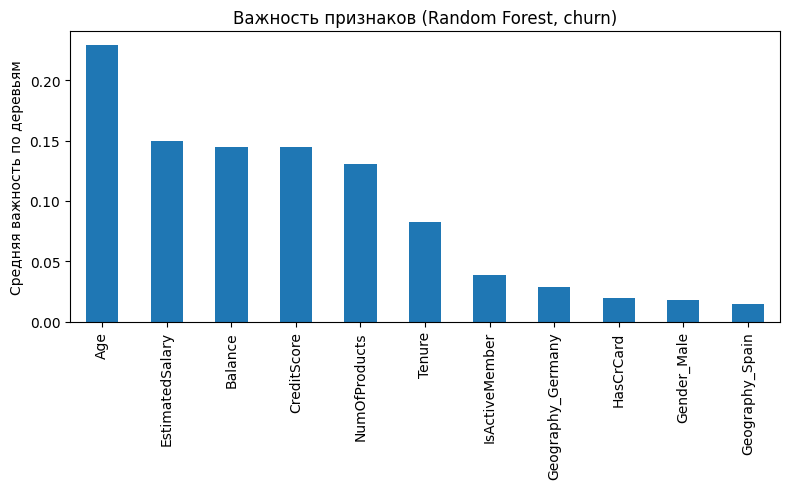

In [31]:
importances = pd.Series(rf_best.feature_importances(), index=X_churn.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar')
plt.title('Важность признаков (Random Forest, churn)')
plt.ylabel('Средняя важность по деревьям')
plt.tight_layout()
plt.show()


### Задание 2.3 (1 балл)

Как и в случае с деревом решений, модифицируйте свою реализацию случайного леса под решение задачи регрессии. Внутри можете использовать свою реализацию из задания 1 или `DecisionTreeRegressor` из `sklearn`.

Сравните качество решения задачи о предсказании продолжительности жизни (те же данные, что в предыдущем задании) с результатами дерева при тех же критериях остановки.

Оцените информативность признаков.

In [32]:
for name, kwargs in REG_CONFIGS.items():
    if 'purity_tol' in kwargs:  # у RandomForest (деревья sklearn) нет аналога purity_tol, сравниваем по двум остальным критериям
        continue
    reg = TreeRegressor(**kwargs).fit(X_train_life, y_train_life)
    rf_life = RandomForest(task='regression', n_estimators=100, random_state=42, **kwargs)
    rf_life.fit(X_train_life, y_train_life)
    for model_name, m in (('TreeRegressor', reg), ('RandomForest', rf_life)):
        preds = m.predict(X_test_life)
        print('%s %s: MSE=%.3f MAE=%.3f R2=%.3f' % (
            model_name, name,
            mean_squared_error(y_test_life, preds),
            mean_absolute_error(y_test_life, preds),
            r2_score(y_test_life, preds)))

importances_life = pd.Series(rf_life.feature_importances(), index=X_life.columns).sort_values(ascending=False)
print(importances_life)


TreeRegressor max_depth=5: MSE=10.981 MAE=2.267 R2=0.845
RandomForest max_depth=5: MSE=8.776 MAE=2.166 R2=0.876
TreeRegressor min_samples_leaf=5: MSE=7.069 MAE=1.648 R2=0.900
RandomForest min_samples_leaf=5: MSE=4.248 MAE=1.376 R2=0.940
Tertiary_School_Enrollment       0.315166
Health_Expenditure_Per_Capita    0.290091
Urban_Population_Rate            0.182628
PM25_AirPollution                0.069418
Population_Density               0.067017
Political_Stability_Index        0.056973
Year                             0.018707
dtype: float64


## Задание 3.1 (3 балла)

Вам необходимо будет реализовать алгоритм градиентного бустинга. В общем смысле бустинг заключается в том, чтобы тренировать каждую последующую модель так, чтобы она исправляла ошибки предыдущих.

Для работы алгоритма помимо данных нужны:
1. количество итераций $M \in \mathbb{N}$;
2. функция потерь $L(y,f)$, где $y$ - истинные значения, $f$ - полученная аппроксимация искомой функции (или просто предсказанные значения).
Важно, чтобы функция потерь была дифференцируемой по $f$;
3. базовая модель, на основе которой делается бустинг - будем использовать деревья решений;
4. начальное приближение $f_0(x)$ - чаще всего используют некую константу.

**Алгоритм:**
1. Задаём начальное приближение функции $f(x) = f_0(x)$ константой - в данном случае можно выбрать ноль, среднее по столбцу с целевым признаком или что-нибудь ещё.
2. Далее итеративно для $t$ от 1 до $M$:
    1. Считаем остатки как $\large r_{t} = -\left[\frac{\partial L(y, f(x))}{\partial f(x)}\right]_{f(x)=\hat{f}(x)}$
    2. Обучаем ещё одну базовую модель $h_t(x)$, при этом нецелевыми признаками у нас будет $x$, а в качестве целевого будем использовать остатки $r_t$, полученные на текущем шаге
    3. Находим оптимальный коэффициент $\rho_t = \underset{\rho}{\arg\min} \ L(y, \hat{f}(x) + \rho \cdot h(x))$
    4. Обновляем текущее приближение $\hat{f}(x) \leftarrow \hat{f}(x) + \hat{f}_i(x)$, где $\hat{f}_i(x) = \rho_t \cdot h_t(x)$
    5. Собираем все полученные базовые алгоритмы в модель $\hat{f}(x) = \sum_{i = 0}^M \hat{f_i}(x)$
    
    
  Коэффициенты $\rho_i$ искать не обязательно, их можно считать равными единице. Однако подбор коэффициентов позволит получить более точные значения, хотя и дополнительно нагрузит алгоритм с вычислительной точки зрения. Коэффициенты выбираются из какого-либо подмножества значений от -1 до 1.

**Функции потерь:**
- $L(y, f) = \frac{1}{2}(y - f)^2$ - _MSE-loss_. Используйте его если считаете, что у модели нет никаких дополнительных требований к стабильности.
- $L(y, f) = |y - f|$ - _MAE-loss_. Применять при требованиях к стабильности модели. Из минусов можно выделить то, что её немного сложнее дифференцировать.
- $\begin{equation} L(y, f) =\left\{ \begin{array}{@{}ll@{}} (1 - \alpha) \cdot |y - f|, & \largeесли\ y-f \leq 0 \\ \alpha \cdot |y - f|, & \largeесли\ y-f >0 \end{array}\right. \end{equation}, \alpha \in (0,1)$ - $L_q$-loss. Применять при наличии особых требований к модели, например, когда нам нужно восстановить не среднее и не медиану условного распределения $(y|x)$, а какую-нибудь квантиль. Штрафует наблюдения, попадающие выше $\alpha$-той квантили.


Реализуйте предложенные функции потерь и их градиенты. В случае, если в вашей выборке не один объект, не забывайте нормировать значения функции потерь.


In [33]:
def mse(y_real, y_predicted):
    return np.mean((y_real - y_predicted) ** 2)

def mse_gradient(y_real, y_predicted):
    return 2 * (y_predicted - y_real)

def mae(y_real, y_predicted):
    return np.mean(np.abs(y_real - y_predicted))

def mae_gradient(y_real, y_predicted):
    return np.sign(y_predicted - y_real)

def lq(y_real, y_predicted, q):
    diff = y_real - y_predicted
    return np.mean(np.where(diff <= 0, (1 - q) * np.abs(diff), q * np.abs(diff)))

def lq_gradient(y_real, y_predicted, q=0.5):
    return np.where(y_predicted - y_real >= 0, q, -(1 - q))


In [34]:
y_real = np.array([1, 2, 3, 4, 5])
y_predicted = np.array([1.2, 2.5, 2.8, 3.9, 5.1])

# Calculate metrics
mse_result = mse(y_real, y_predicted)
mae_result = mae(y_real, y_predicted)
lq_result = lq(y_real, y_predicted, q=0.8)

# Calculate gradients
mse_grad = mse_gradient(y_real, y_predicted)
mae_grad = mae_gradient(y_real, y_predicted)
lq_grad = lq_gradient(y_real, y_predicted, q=0.8)

# Tests
assert np.isclose(mse_result, 0.07)
assert np.isclose(mae_result, 0.22, atol=1e-6)
assert np.isclose(lq_result, 0.08, atol=1e-6)
assert np.allclose(mse_grad, np.array([0.4, 1, -0.4, -0.2, 0.2]))
assert np.allclose(mae_grad, np.array([1, 1, -1, -1, 1]))
assert np.allclose(lq_grad, np.array([0.8, 0.8, -0.2, -0.2, 0.8]))

print("Tests passed successfully!")

Tests passed successfully!


Реализуйте алгоритм градиентного бустинга со следующими параметрами:

* список, в котором вы будете хранить обученные деревья;
* параметры конструктора для деревьев (tree_kwargs);
* функция потерь;
* градиент функции потерь;
* bool параметр, означающий, является ли $\rho_i$ константой (единицей).

И методами:
* `fit` - в рамках этого метода вам необходимо будет строить деревья. Не забывайте передавать tree_kwargs;
* `predict` - этот метод должен последовательно применить обученные деревья для получения итогового ответа.

В качестве базового алгоритма используйте DecisionTreeRegressor из sklearn. Обычно для градиентного бустинга используют так называемые "пеньки" - деревья небольшой глубины. Это связано с тем, что алгоритм должен иметь высокую обобщающую способность и не переобучаться.


In [35]:
from sklearn.tree import DecisionTreeRegressor


losses = {
    'MSE': (mse, mse_gradient),
    'MAE': (mae, mae_gradient),
    'lq': (lq, lq_gradient),
}


class GradientTreeBoosting:
    def __init__(self, loss='MSE', iterations=100, const_p=True, random_state=None, **tree_kwargs):
        self.loss_fn, self.grad_fn = losses[loss]
        self.iterations = iterations
        self.const_p = const_p
        self.tree_kwargs = tree_kwargs
        self.random_state = random_state
        self.trees = []
        self.rhos = []
        self.f0 = None

    def fit(self, X, y):
        X = X.values if hasattr(X, 'values') else np.asarray(X)
        y = y.values if hasattr(y, 'values') else np.asarray(y)
        self.f0 = y.mean()
        f = np.full(len(y), self.f0, dtype=float)
        self.trees, self.rhos = [], []

        for _ in range(self.iterations):
            residual = -self.grad_fn(y, f)  # r_t = -[dL/df]
            tree = DecisionTreeRegressor(random_state=self.random_state, **self.tree_kwargs)
            tree.fit(X, residual)
            h = tree.predict(X)

            if self.const_p:
                rho = 1.0
            else:
                candidates = np.linspace(-1, 1, 41)  # rho ищем перебором на [-1, 1]
                rho = candidates[np.argmin([self.loss_fn(y, f + r * h) for r in candidates])]

            f = f + rho * h
            self.trees.append(tree)
            self.rhos.append(rho)
        return self

    def predict(self, X):
        X = X.values if hasattr(X, 'values') else np.asarray(X)
        f = np.full(X.shape[0], self.f0, dtype=float)
        for tree, rho in zip(self.trees, self.rhos):
            f = f + rho * tree.predict(X)
        return f


## Задание 3.2 (2 балла)

Проверим на игрушечном примере, что алгоритм работает. Если ваша реализация отличается от используемой в примере - поправьте код примера. Но результат должен получаться похожим.

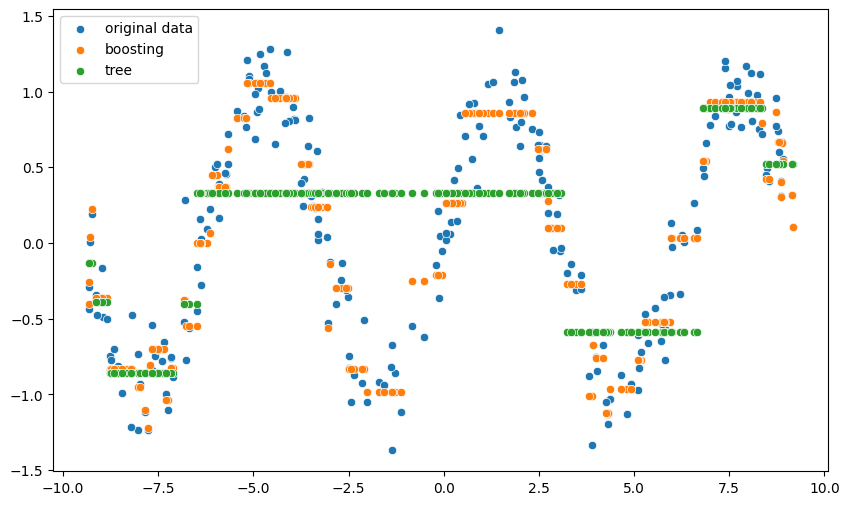

In [36]:
# генерируем данные
np.random.seed(42)
x = np.random.uniform(low=-3*np.pi, high=3*np.pi, size=(250))
y = np.sin(x) + np.random.randn(250) * 0.2

# обучаем обычное дерево глубины 3
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(x.reshape(-1, 1), y)

# обучаем бустинг-ансамбль
clf = GradientTreeBoosting(loss='MSE', iterations=10, const_p=False,
                           max_depth=3, random_state=42)
clf.fit(x.reshape(-1, 1), y)

# смотрим, что вышло|
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, label='original data')
sns.scatterplot(x=x, y=clf.predict(x.reshape(-1, 1)), label='boosting')
sns.scatterplot(x=x, y=tree.predict(x.reshape(-1, 1)), label='tree')
plt.show()

Примените алгоритм к тем же данным, с которыми работали в предыдущем задании для решения задачи классификации (https://www.kaggle.com/mathchi/churn-for-bank-customers). Предсказывать будем не класс (0/1), а логиты, то есть вероятность того, что клиент уйдёт, и на основе неё уже делать прогноз, определяя класс относительно некого порога (по умолчанию 0.5).

In [37]:
def decide_class(logits, threshold=0.5):
    res = np.zeros(logits.shape[0])
    res[logits >= threshold] = 1
    return res


Сравните вашу реализацию градиентного бустинга (с константным $\rho$ и нет) с одиночным DecisionTreeRegressor по качеству и времени выполнения. При неконстантном $\rho$ качество должно возрасти.

В качестве набора данных для сравнения используйте этот датасет: https://www.kaggle.com/mathchi/churn-for-bank-customers

In [38]:
%%time
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train_churn, y_train_churn)
tree_pred = decide_class(tree_reg.predict(X_test_churn))


CPU times: total: 0 ns
Wall time: 11 ms


In [39]:
%%time
gbt_const = GradientTreeBoosting(loss='MSE', iterations=50, const_p=True, max_depth=3, random_state=42)
gbt_const.fit(X_train_churn, y_train_churn)
gbt_const_pred = decide_class(gbt_const.predict(X_test_churn))


CPU times: total: 469 ms
Wall time: 478 ms


In [40]:
%%time
gbt_line = GradientTreeBoosting(loss='MSE', iterations=50, const_p=False, max_depth=3, random_state=42)
gbt_line.fit(X_train_churn, y_train_churn)
gbt_line_pred = decide_class(gbt_line.predict(X_test_churn))


CPU times: total: 516 ms
Wall time: 518 ms


In [41]:
for name, pred in [('single tree', tree_pred),
                   ('boosting const_p=True', gbt_const_pred),
                   ('boosting const_p=False', gbt_line_pred)]:
    print('%s: accuracy=%.3f f1=%.3f' % (
        name, accuracy_score(y_test_churn, pred), f1_score(y_test_churn, pred)))


single tree: accuracy=0.855 f1=0.552
boosting const_p=True: accuracy=0.796 f1=0.000
boosting const_p=False: accuracy=0.854 f1=0.573
